- Part f

Plotting the cell concentrations and productivities as a function of the dilution rate for different values of 𝛼. 

Below are the plots of the selectivity for 𝛼 values: 0, 0.3, 0.6, and 0.8.

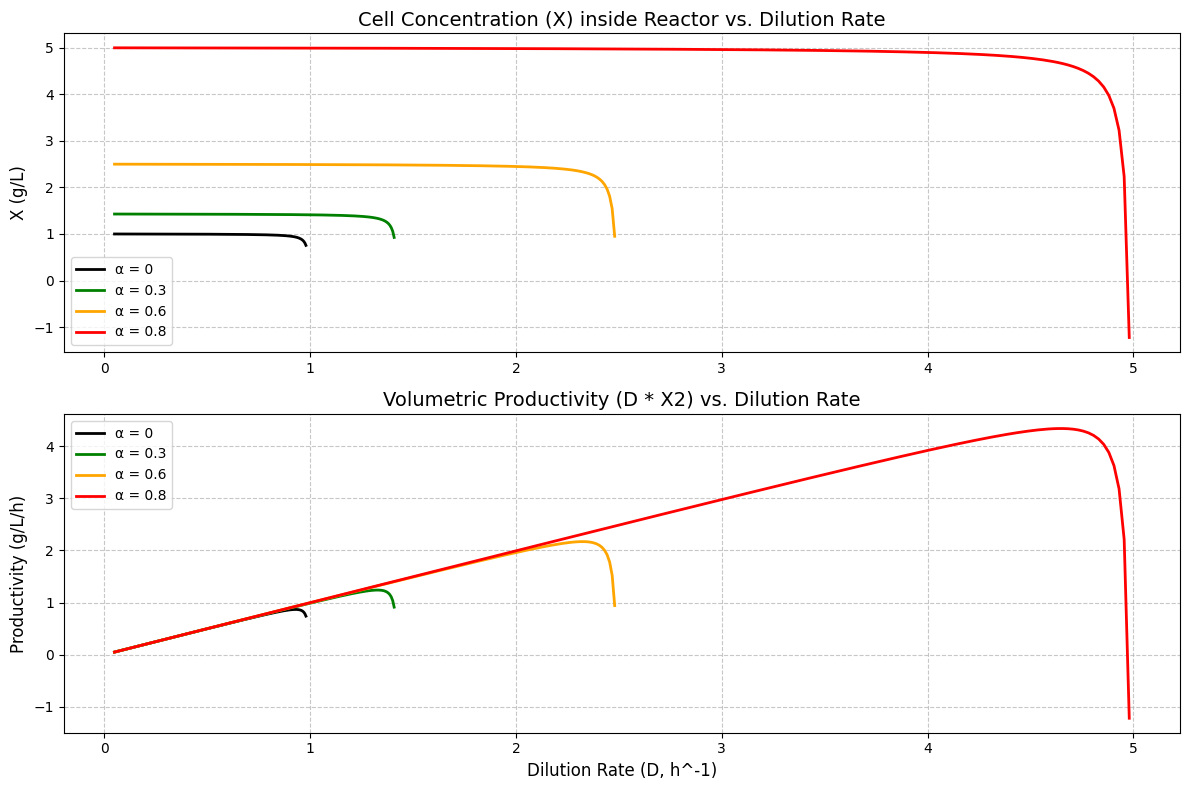

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters based on your previous problem parts
mu_m = 1.0      # h^-1 (max specific growth rate)
Ks = 0.01       # g/L (half-saturation constant)
Yxs = 0.5       # g/g (yield coefficient)
S0 = 2.0        # g/L (feed substrate concentration)
C = 2.0         # concentration factor

# Recycle ratios to compare
alphas = [0, 0.3, 0.6, 0.8]
colors = ['black', 'green', 'orange', 'red']

plt.figure(figsize=(12, 8))

for alpha, color in zip(alphas, colors):
    # Calculate D_max for this specific alpha
    # D_max = mu_m / (1 + alpha*(1 - C))
    # Since C=2, denominator is (1 - alpha)
    D_max = mu_m / (1 - alpha)
    
    # Generate Dilution rates from 0.05 to just below D_max
    D = np.linspace(0.05, D_max - 0.02, 200)
    
    # Calculate mu, S, X, and Productivity (D*X2)
    mu = D * (1 + alpha - alpha * C)
    S = (Ks * mu) / (mu_m - mu)
    X = (Yxs * (S0 - S)) / (1 + alpha - alpha * C)
    
    # X2 is the concentration in the final effluent
    X2 = X * (1 + alpha - alpha * C)
    Productivity = D * X2
    
    # Plot Cell Concentration (X) in the reactor
    plt.subplot(2, 1, 1)
    plt.plot(D, X, label=f'α = {alpha}', color=color, linewidth=2)
    
    # Plot Productivity (D*X2)
    plt.subplot(2, 1, 2)
    plt.plot(D, Productivity, label=f'α = {alpha}', color=color, linewidth=2)

# Formatting Top Plot (Cell Concentration)
plt.subplot(2, 1, 1)
plt.title('Cell Concentration (X) inside Reactor vs. Dilution Rate', fontsize=14)
plt.ylabel('X (g/L)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Formatting Bottom Plot (Productivity)
plt.subplot(2, 1, 2)
plt.title('Volumetric Productivity (D * X2) vs. Dilution Rate', fontsize=14)
plt.xlabel('Dilution Rate (D, h^-1)', fontsize=12)
plt.ylabel('Productivity (g/L/h)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()